# 00 - EDA: Inventory of dataset for mortality / morbidity regression

This notebook is the **gate** for the rest of the pipeline. Its job is to:

1. Inventory every CSV in `./data/` (the published CCHAIN flat tables available in the Google Drive).
1. Classify each table by role (target / feature / dimension), key (ADM3 / ADM4), and time granularity.
1. Profile the candidate **targets** (PIDSR cases, PSA deaths, FHSIS) for distribution, sparsity, coverage.
1. Profile **features** for missingness, range, and per-city coverage.
1. Confirm joinability across `adm3_pcode` / `adm4_pcode` / `date`.
1. Emit `feature_inventory.csv` -- a single row per candidate feature with a keep/drop decision that drives the succeeding steps in the pipeline.

In [34]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

In [13]:
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data"
PROC_DIR = REPO_ROOT / "data" / "processed"
EDA_OUT = REPO_ROOT / "data" / "processed" / "eda"
EDA_OUT.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

print("REPO_ROOT :", REPO_ROOT.name)
print("DATA_DIR  :", DATA_DIR.relative_to(REPO_ROOT))
print("EDA_OUT   :", EDA_OUT.relative_to(REPO_ROOT))

REPO_ROOT : morbidity-mortality-modelling
DATA_DIR  : data
EDA_OUT   : data/processed/eda


## 1. File inventory

Walk `data/` (one level deep) and capture: filename, size in MB, line count (proxy for rows), preview of first row, and detected separator. Sub-directories are listed but not recursed.

In [14]:
def quick_line_count(path, max_bytes=200_000_000):
    """Approx row count. Reads up to max_bytes for huge files and extrapolates."""
    size = path.stat().st_size
    if size <= max_bytes:
        with path.open("rb") as f:
            return sum(1 for _ in f) - 1, False  # minus header
    sampled = 0
    with path.open("rb") as f:
        for i, _ in enumerate(f):
            sampled = i
            if f.tell() >= max_bytes:
                break
    approx = int(sampled * (size / max_bytes))
    return approx, True


rows = []
for p in sorted(DATA_DIR.glob("*")):
    if p.is_dir():
        rows.append({"name": p.name + "/", "size_mb": None, "rows": None, "approx": False, "kind": "dir"})
        continue
    if p.suffix.lower() != ".csv":
        rows.append({"name": p.name, "size_mb": round(p.stat().st_size / 1e6, 2), "rows": None, "approx": False, "kind": p.suffix or "file"})
        continue
    n, approx = quick_line_count(p)
    rows.append({"name": p.name, "size_mb": round(p.stat().st_size / 1e6, 2), "rows": n, "approx": approx, "kind": "csv"})

inv_df = pd.DataFrame(rows)
inv_df

,name,size_mb,rows,approx,kind
0,.DS_Store,0.01,NaN,False,file
1,brgy_geography.csv,7.03,879.0,False,csv
2,calendar.csv,0.08,7305.0,False,csv
3,climate_air_quality.csv,456.72,6428933.0,True,csv
4,climate_atmosphere.csv,570.04,6424862.0,True,csv
5,climate_atmosphere_downscaled.csv,326.69,5910874.0,True,csv
6,climate_indices.csv,12.79,210720.0,False,csv
7,climate_land.csv,268.99,6420446.0,True,csv
8,climate_timestep_check.csv,276.11,6421094.0,True,csv
9,disease.csv,0.00,17.0,False,csv


## 2. Schema preview

For each CSV, show first 2 rows and dtypes. For files >100 MB we only sniff the header + 5000 rows so memory stays bounded.

In [15]:
BIG_FILE_PREVIEW_ROWS = 5000
BIG_THRESHOLD_MB = 100

schemas = {}
for _, row in inv_df.iterrows():
    if row["kind"] != "csv":
        continue
    path = DATA_DIR / row["name"]
    is_big = (row["size_mb"] or 0) > BIG_THRESHOLD_MB
    kwargs = {"nrows": BIG_FILE_PREVIEW_ROWS} if is_big else {}
    try:
        df = pd.read_csv(path, **kwargs)
    except Exception as e:  # noqa: BLE001
        print(f"!! {row['name']}: failed to read ({e})")
        continue
    schemas[row["name"]] = {
        "columns": list(df.columns),
        "dtypes": {c: str(t) for c, t in df.dtypes.items()},
        "sample_rows": int(len(df)),
        "is_preview": is_big,
    }

schemas_summary = pd.DataFrame(
    [
        {"name": n, "n_cols": len(s["columns"]), "preview_only": s["is_preview"], "columns": ", ".join(s["columns"])}
        for n, s in schemas.items()
    ]
)
schemas_summary

,name,n_cols,preview_only,columns
0,brgy_geography.csv,8,False,"uuid, adm4_pcode, date, freq, brgy_total_area,..."
1,calendar.csv,1,False,date
2,climate_air_quality.csv,10,True,"uuid, adm4_pcode, date, freq, no2, co, so2, o3..."
3,climate_atmosphere.csv,13,True,"uuid, adm4_pcode, date, freq, tave, tmin, tmax..."
4,climate_atmosphere_downscaled.csv,8,True,"uuid, adm4_pcode, date, freq, tmin_downscaled,..."
5,climate_indices.csv,8,False,"uuid, adm4_pcode, date, freq, pr_norm, spi3, s..."
6,climate_land.csv,5,True,"uuid, adm4_pcode, date, freq, ndvi"
7,climate_timestep_check.csv,6,True,"uuid, adm4_pcode, date, freq, co_n_timesteps_a..."
8,disease.csv,3,False,"disease_icd10_code, disease_common_name, disea..."
9,disease_fhsis_totals.csv,10,False,"uuid, freq, date, source_name, source_filename..."


In [16]:
# Per-file head(2) + dtypes for closer inspection
for name, s in schemas.items():
    path = DATA_DIR / name
    df = pd.read_csv(path, nrows=2)
    print(f"=== {name} (cols={len(s['columns'])}, preview_only={s['is_preview']}) ===")
    print(df.dtypes.to_string())
    display(df)
    print()

=== brgy_geography.csv (cols=8, preview_only=False) ===
uuid                          str
adm4_pcode                    str
date                          str
freq                          str
brgy_total_area           float64
brgy_distance_to_coast    float64
brgy_is_coastal              bool
geometry                      str


,uuid,adm4_pcode,date,freq,brgy_total_area,brgy_distance_to_coast,brgy_is_coastal,geometry
0,BGEOG000000,PH050506053,2003-01-01,S,0.8428,990.730626,False,"POLYGON ((123.735986255 13.189494837, 123.7402..."
1,BGEOG000001,PH050506056,2003-01-01,S,7.0818,0.000000,True,"POLYGON ((123.758319446 13.0930309230001, 123...."



=== calendar.csv (cols=1, preview_only=False) ===
date    str


,date
0,2003-01-01
1,2003-01-02



=== climate_air_quality.csv (cols=10, preview_only=True) ===
uuid              str
adm4_pcode        str
date              str
freq              str
no2           float64
co            float64
so2           float64
o3            float64
pm10          float64
pm25          float64


...

,adm3_pcode,adm4_pcode,tile_id,osm_id,settlement_type,roof_material,roof_layout,roof_area,is_gated,density,height,geometry
0,PH015518000,PH015518022,T00005,317043667,nonsettlement,NaN,NaN,575.6,False,single,low,"POLYGON ((120.330493190585 16.0454645098642,12..."
1,PH015518000,PH015518022,T00005,317043688,settlement,natural-gi-mixed,single-layer-basic,123.2,False,single,NaN,"POLYGON ((120.330027290585 16.0460482098641,12..."



=== tm_relative_wealth_index.csv (cols=9, preview_only=False) ===
uuid              str
adm4_pcode        str
date              str
freq              str
rwi_max       float64
rwi_mean      float64
rwi_median    float64
rwi_min       float64
rwi_std       float64


,uuid,adm4_pcode,date,freq,rwi_max,rwi_mean,rwi_median,rwi_min,rwi_std
0,TMRWI000000,PH015518001,2016-01-01,Y,0.729052,0.668600,0.670609,0.636570,0.030640
1,TMRWI000001,PH112402081,2016-01-01,Y,0.657610,0.531397,0.530826,0.453885,0.035633



=== worldpop_population.csv (cols=15, preview_only=False) ===
uuid                      str
adm4_pcode                str
date                      str
freq                      str
pop_count_total       float64
pop_count_mean        float64
pop_count_median      float64
pop_count_stdev       float64
pop_count_min         float64
pop_count_max         float64
pop_density_mean      float64
pop_density_median    float64
pop_density_stdev     float64
pop_density_min       float64
pop_density_max       float64


,uuid,adm4_pcode,date,freq,pop_count_total,pop_count_mean,pop_count_median,pop_count_stdev,pop_count_min,pop_count_max,pop_density_mean,pop_density_median,pop_density_stdev,pop_density_min,pop_density_max
0,WDPOP000000,PH137503007,2000-01-01,Y,3350.263672,558.377279,545.798828,48.654772,516.175537,661.617249,NaN,NaN,NaN,NaN,NaN
1,WDPOP000001,PH063022152,2000-01-01,Y,1492.030518,14.346447,14.088117,9.941083,1.157729,39.577888,1747.875977,1747.875977,0.0,1747.875977,1747.875977


## 3. Classify every table

Manually tag each file by (role, key, time-granularity). This classification is the contract for downstream notebooks.

In [17]:
TABLE_TAGS = {
    # role:     target | feature | dimension | lookup
    # key:      adm3 | adm4 | none
    # gran:     daily | weekly | monthly | annual | static | none
    # target_role for the disease tables
    "disease.csv":                              {"role": "lookup",    "key": "none", "gran": "none"},
    "disease_pidsr_totals.csv":                 {"role": "target",    "key": "adm3", "gran": "weekly",  "outcome": "cases"},
    "disease_psa_totals.csv":                   {"role": "target",    "key": "adm3", "gran": "weekly",  "outcome": "deaths"},
    "disease_fhsis_totals.csv":                 {"role": "target",    "key": "adm3", "gran": "monthly", "outcome": "cases+deaths"},
    "disease_lgu_disaggregated_totals.csv":     {"role": "target",    "key": "adm4", "gran": "monthly", "outcome": "cases+deaths"},
    "location.csv":                             {"role": "dimension", "key": "adm4", "gran": "static"},
    "calendar.csv":                             {"role": "dimension", "key": "none", "gran": "daily"},
    "brgy_geography.csv":                       {"role": "feature",   "key": "adm4", "gran": "static"},
    "climate_air_quality.csv":                  {"role": "feature",   "key": "adm4", "gran": "daily_or_weekly"},
    "climate_atmosphere.csv":                   {"role": "feature",   "key": "adm4", "gran": "daily_or_weekly"},
    "climate_atmosphere_downscaled.csv":        {"role": "feature",   "key": "adm4", "gran": "daily_or_weekly"},
    "climate_indices.csv":                      {"role": "feature",   "key": "adm4", "gran": "monthly"},
    "climate_land.csv":                         {"role": "feature",   "key": "adm4", "gran": "daily_or_weekly"},
    "climate_timestep_check.csv":               {"role": "diagnostic","key": "none", "gran": "none"},
    "esa_worldcover.csv":                       {"role": "feature",   "key": "adm4", "gran": "static"},
    "geoportal_doh_poi_health.csv":             {"role": "feature",   "key": "adm4", "gran": "static"},
    "google_open_buildings.csv":                {"role": "feature",   "key": "adm4", "gran": "static"},
    "mapbox_health_facility_brgy_isochrones.csv":{"role": "feature",   "key": "adm4", "gran": "static"},
    "mapbox_health_facility_city_isochrones.csv":{"role": "feature",   "key": "adm3", "gran": "static"},
    "nighttime_lights.csv":                     {"role": "feature",   "key": "adm4", "gran": "annual"},
    "ookla_internet_speed.csv":                 {"role": "feature",   "key": "adm4", "gran": "annual"},
    "osm_poi_amenity.csv":                      {"role": "feature",   "key": "adm4", "gran": "annual_or_static"},
    "osm_poi_health.csv":                       {"role": "feature",   "key": "adm4", "gran": "annual_or_static"},
    "osm_poi_sanitation.csv":                   {"role": "feature",   "key": "adm4", "gran": "annual_or_static"},
    "osm_poi_total.csv":                        {"role": "feature",   "key": "adm4", "gran": "annual_or_static"},
    "osm_poi_water_body.csv":                   {"role": "feature",   "key": "adm4", "gran": "annual_or_static"},
    "project_noah_hazards.csv":                 {"role": "feature",   "key": "adm4", "gran": "static"},
    "tm_open_buildings.csv":                    {"role": "feature",   "key": "adm4", "gran": "static"},
    "tm_relative_wealth_index.csv":             {"role": "feature",   "key": "adm4", "gran": "annual"},
    "worldpop_population.csv":                  {"role": "feature",   "key": "adm4", "gran": "annual"},
}

tagged = pd.DataFrame.from_dict(TABLE_TAGS, orient="index").reset_index().rename(columns={"index": "name"})
tagged = tagged.merge(inv_df[["name", "size_mb", "rows"]], on="name", how="left")
tagged.sort_values(["role", "key", "gran", "name"])

,name,role,key,gran,outcome,size_mb,rows
13,climate_timestep_check.csv,diagnostic,none,none,NaN,276.11,6421094.0
5,location.csv,dimension,adm4,static,NaN,0.09,879.0
6,calendar.csv,dimension,none,daily,NaN,0.08,7305.0
18,mapbox_health_facility_city_isochrones.csv,feature,adm3,static,NaN,0.00,12.0
19,nighttime_lights.csv,feature,adm4,annual,NaN,1.03,9669.0
20,ookla_internet_speed.csv,feature,adm4,annual,NaN,0.75,3516.0
28,tm_relative_wealth_index.csv,feature,adm4,annual,NaN,0.80,6153.0
29,worldpop_population.csv,feature,adm4,annual,NaN,3.59,18459.0
21,osm_poi_amenity.csv,feature,adm4,annual_or_static,NaN,2.66,7911.0
22,osm_poi_health.csv,feature,adm4,annual_or_static,NaN,1.11,7911.0


## 4. Targets deep-dive

We focus on **PIDSR (weekly cases)** + **PSA (weekly deaths)** as the recommended target pair, with FHSIS as a monthly check.

In [18]:
def load_target(name):
    df = pd.read_csv(DATA_DIR / name, parse_dates=["date"])
    return df

pidsr = load_target("disease_pidsr_totals.csv")
psa   = load_target("disease_psa_totals.csv")
fhsis = load_target("disease_fhsis_totals.csv")

def target_summary(df, outcome_col, label):
    return {
        "source": label,
        "rows": len(df),
        "date_min": df["date"].min(),
        "date_max": df["date"].max(),
        "n_adm3": df["adm3_pcode"].nunique() if "adm3_pcode" in df else None,
        "n_diseases": df["disease_icd10_code"].nunique() if "disease_icd10_code" in df else None,
        f"{outcome_col}_null_pct": df[outcome_col].isna().mean() * 100 if outcome_col in df else None,
        f"{outcome_col}_zero_pct": (df[outcome_col].fillna(0) == 0).mean() * 100 if outcome_col in df else None,
        f"{outcome_col}_total": df[outcome_col].sum(skipna=True) if outcome_col in df else None,
    }

summary = pd.DataFrame([
    target_summary(pidsr, "case_total", "PIDSR cases"),
    target_summary(psa,   "death_total", "PSA deaths"),
    target_summary(fhsis, "case_total", "FHSIS cases"),
    target_summary(fhsis, "death_total", "FHSIS deaths"),
])
summary

,source,rows,date_min,date_max,n_adm3,n_diseases,case_total_null_pct,case_total_zero_pct,case_total_total,death_total_null_pct,death_total_zero_pct,death_total_total
0,PIDSR cases,74880,2008-01-07,2022-12-26,12,9,0.000000,74.512553,307468.0,NaN,NaN,NaN
1,PSA deaths,41577,2006-01-01,2021-12-27,12,13,NaN,NaN,NaN,0.000000,11.720422,162591.0
2,FHSIS cases,2112,2013-01-01,2023-11-20,6,12,54.545455,96.590909,23097.0,NaN,NaN,NaN
3,FHSIS deaths,2112,2013-01-01,2023-11-20,6,12,NaN,NaN,NaN,45.454545,92.992424,5371.0


**PIDSR cases** — 74,880 weekly rows, all 12 cities, 9 diseases, 2008–2022 (15 years), zero NULLs. 75% of rows are zero — i.e. for most (city, disease, week) cells nothing was reported, which is normal for surveillance data. Total cases in the panel: 307k. This is the best target candidate: full coverage, long span, weekly granularity.

**PSA deaths** — 41,577 weekly rows, all 12 cities, 13 diseases, 2006–2021 (16 years), zero NULLs, only 12% zero — deaths are denser per cell than cases. Total deaths: 162k. The mortality counterpart to PIDSR, joinable on (adm3_pcode, date).

These will be used as target variables for the models to be developed.

In [19]:
# Top ICD-10 codes by total volume in PIDSR (cases) and PSA (deaths)
disease_lookup = pd.read_csv(DATA_DIR / "disease.csv")

top_pidsr = (
    pidsr.groupby(["disease_icd10_code", "disease_common_name"], as_index=False)["case_total"]
    .sum()
    .sort_values("case_total", ascending=False)
    .head(15)
)
top_psa = (
    psa.groupby(["disease_icd10_code", "disease_common_name"], as_index=False)["death_total"]
    .sum()
    .sort_values("death_total", ascending=False)
    .head(15)
)
print("Top 15 PIDSR diseases by total cases:")
display(top_pidsr)
print("\nTop 15 PSA diseases by total deaths:")
display(top_psa)

Top 15 PIDSR diseases by total cases:


,disease_icd10_code,disease_common_name,case_total
6,A90-A91,DENGUE FEVER,265372
1,A01,TYPHOID FEVER,21917
4,A27,LEPTOSPIROSIS,8034
3,A09.0,ACUTE BLOODY DIARRHEA,6021
8,B15,HEPATITIS A,1958
2,A08,ROTAVIRAL ENTERITIS,1847
0,A00,CHOLERA,1814
7,A92,CHIKUNGUYA VIRAL DISEASE,314
5,A82,RABIES,191



Top 15 PSA diseases by total deaths:


,disease_icd10_code,disease_common_name,death_total
10,I21-I22,ISCHEMIC HEART DISEASE,84427
7,E08-E14,DIABETES,40246
8,I11,HYPERTENSIVE HEART DISEASE,19216
2,A09,GASTROENTERITIS,5302
11,J45,ASTHMA,4743
5,A90-A91,DENGUE FEVER,3625
9,I20-I25,ANGINA,1839
3,A27,LEPTOSPIROSIS,1663
4,A82,RABIES,765
1,A01,TYPHOID FEVER,635


In [20]:
# Build the candidate target: all-cause weekly cases (PIDSR) + deaths (PSA), summed across diseases
cases_w = pidsr.groupby(["adm3_pcode", "date"], as_index=False)["case_total"].sum().rename(columns={"case_total": "all_cause_cases"})
deaths_w = psa.groupby(["adm3_pcode", "date"], as_index=False)["death_total"].sum().rename(columns={"death_total": "all_cause_deaths"})

target_w = cases_w.merge(deaths_w, on=["adm3_pcode", "date"], how="outer").sort_values(["adm3_pcode", "date"])
print("Combined weekly target shape:", target_w.shape)
print("Cities present:", target_w["adm3_pcode"].nunique())
print("Date range:", target_w["date"].min(), "to", target_w["date"].max())
target_w.describe(include="all").T

Combined weekly target shape: (10712, 4)
Cities present: 12
Date range: 2006-01-01 00:00:00 to 2022-12-26 00:00:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
adm3_pcode,10712,12,PH112402000,899,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,10712,NaN,NaN,NaN,2014-07-15 22:52:39.073935,2006-01-01 00:00:00,2010-04-26 00:00:00,2014-07-21 00:00:00,2018-10-08 00:00:00,2022-12-26 00:00:00,NaN
all_cause_cases,9360.0,NaN,NaN,NaN,32.849145,0.0,3.0,11.0,35.0,2407.0,79.044596
all_cause_deaths,9536.0,NaN,NaN,NaN,17.050231,0.0,8.0,13.0,23.0,128.0,13.313165


In [21]:
target_w

,adm3_pcode,date,all_cause_cases,all_cause_deaths
0,PH015518000,2006-01-01,NaN,9.0
1,PH015518000,2006-01-02,NaN,13.0
2,PH015518000,2006-01-09,NaN,7.0
3,PH015518000,2006-01-16,NaN,4.0
4,PH015518000,2006-01-23,NaN,7.0
...,...,...,...,...
10707,PH137603000,2022-11-28,28.0,NaN
10708,PH137603000,2022-12-05,22.0,NaN
10709,PH137603000,2022-12-12,15.0,NaN
10710,PH137603000,2022-12-19,9.0,NaN


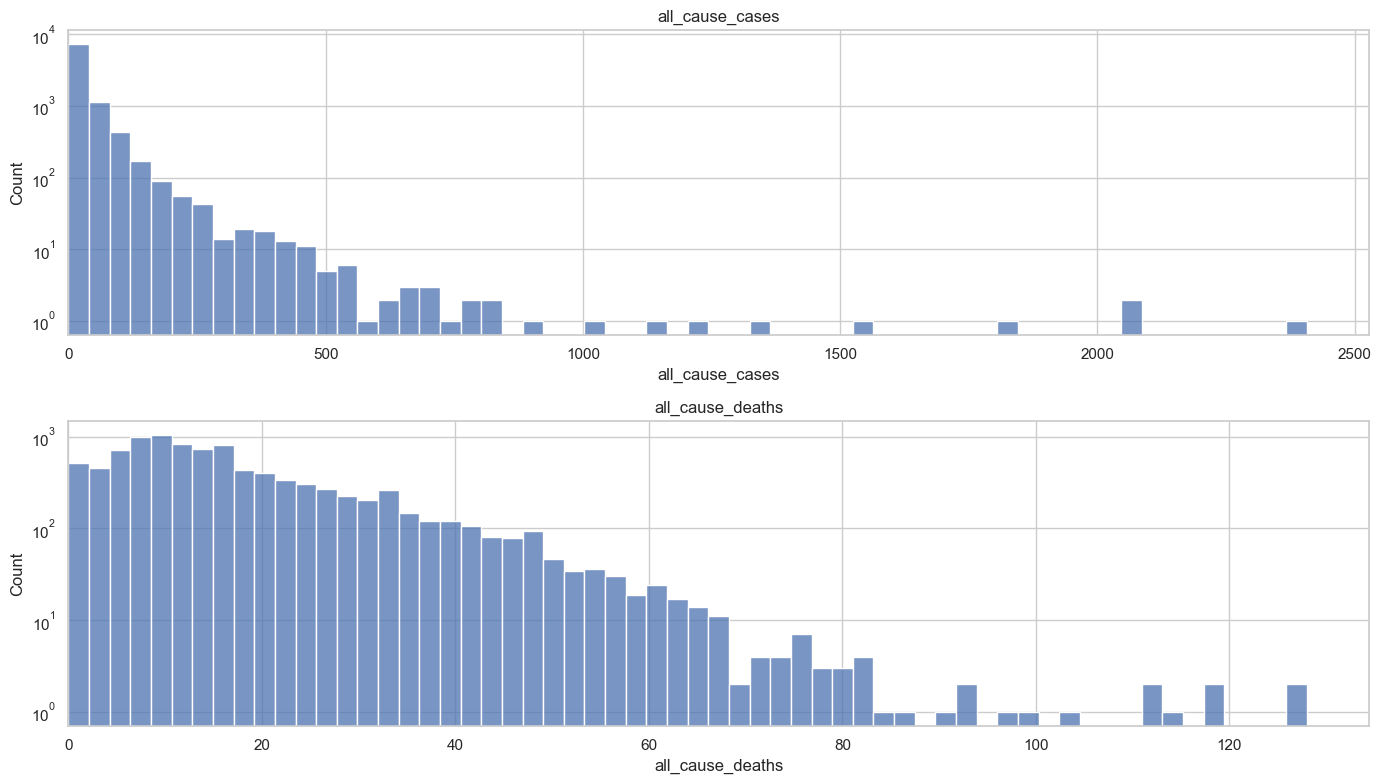

Zero-inflation rates:
  all_cause_cases: 20.6% zero-valued rows
  all_cause_deaths: 11.1% zero-valued rows


In [22]:
# Distribution of the two targets
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, col in zip(axes, ["all_cause_cases", "all_cause_deaths"]):
    sns.histplot(target_w[col].dropna(), bins=60, ax=ax)
    ax.set_title(col)
    ax.set_yscale("log")
    ax.set_xlim(0)

plt.tight_layout()
plt.show()

print("Zero-inflation rates:")
for c in ["all_cause_cases", "all_cause_deaths"]:
    z = (target_w[c].fillna(0) == 0).mean()
    print(f"  {c}: {z:.1%} zero-valued rows")

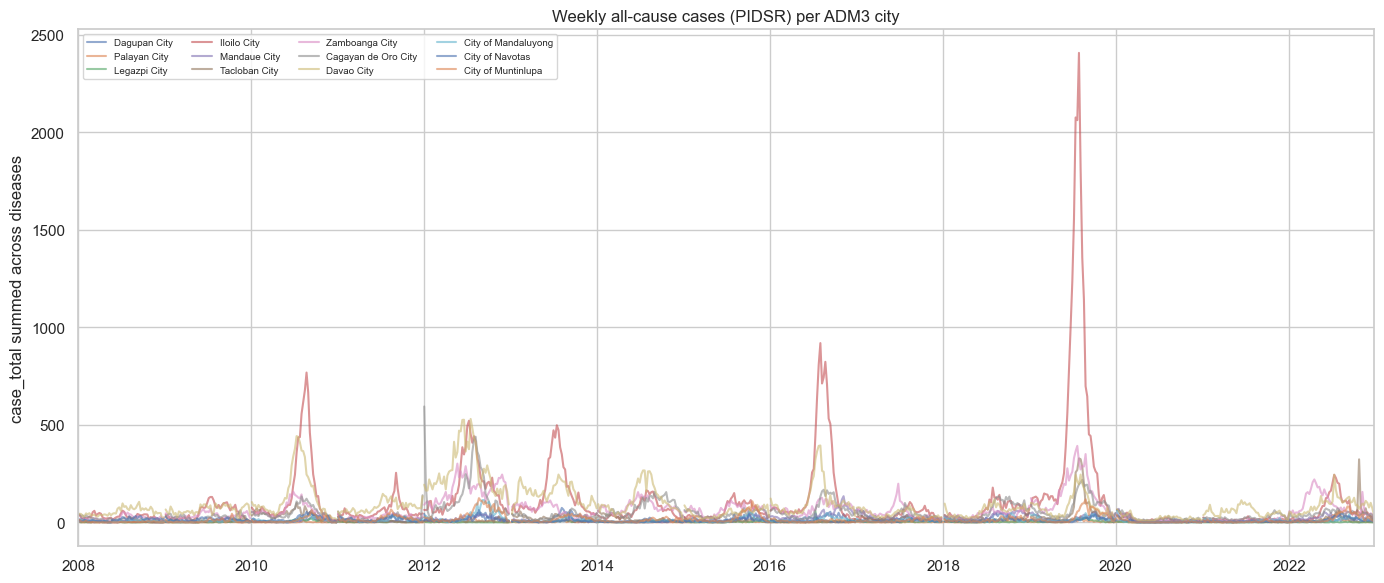

In [23]:
# Time series per city - all-cause cases
# Build an ADM3 pcode -> city name lookup from location.csv so the legend is readable.
pcode_to_name = (
    pd.read_csv(DATA_DIR / "location.csv")
    .drop_duplicates("adm3_pcode")
    .set_index("adm3_pcode")["adm3_en"]
    .to_dict()
)

fig, ax = plt.subplots(figsize=(14, 6))
for pcode, sub in target_w.groupby("adm3_pcode"):
    ax.plot(sub["date"], sub["all_cause_cases"], alpha=0.6, label=pcode_to_name.get(pcode, pcode))
ax.set_title("Weekly all-cause cases (PIDSR) per ADM3 city")
ax.set_ylabel("case_total summed across diseases")
ax.set_xlim(pd.Timestamp("2008-01-01"), target_w["date"].max())
ax.legend(ncol=4, fontsize=7, loc="upper left")
plt.tight_layout()
plt.show()

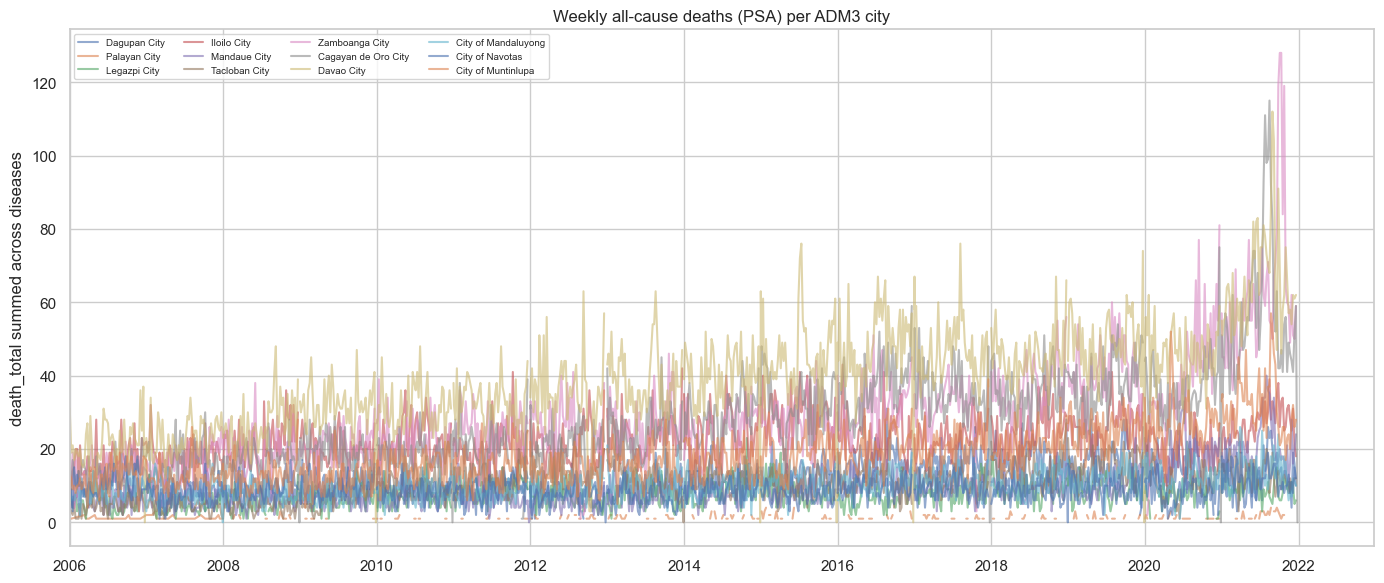

In [35]:
# Time series per city - all-cause deaths
fig, ax = plt.subplots(figsize=(14, 6))
for pcode, sub in target_w.groupby("adm3_pcode"):
    ax.plot(sub["date"], sub["all_cause_deaths"], alpha=0.6, label=pcode_to_name.get(pcode, pcode))
ax.set_title("Weekly all-cause deaths (PSA) per ADM3 city")
ax.set_ylabel("death_total summed across diseases")
ax.legend(ncol=4, fontsize=7, loc="upper left")
ax.set_xlim(target_w["date"].min(), target_w["date"].max())
plt.tight_layout()
plt.show()

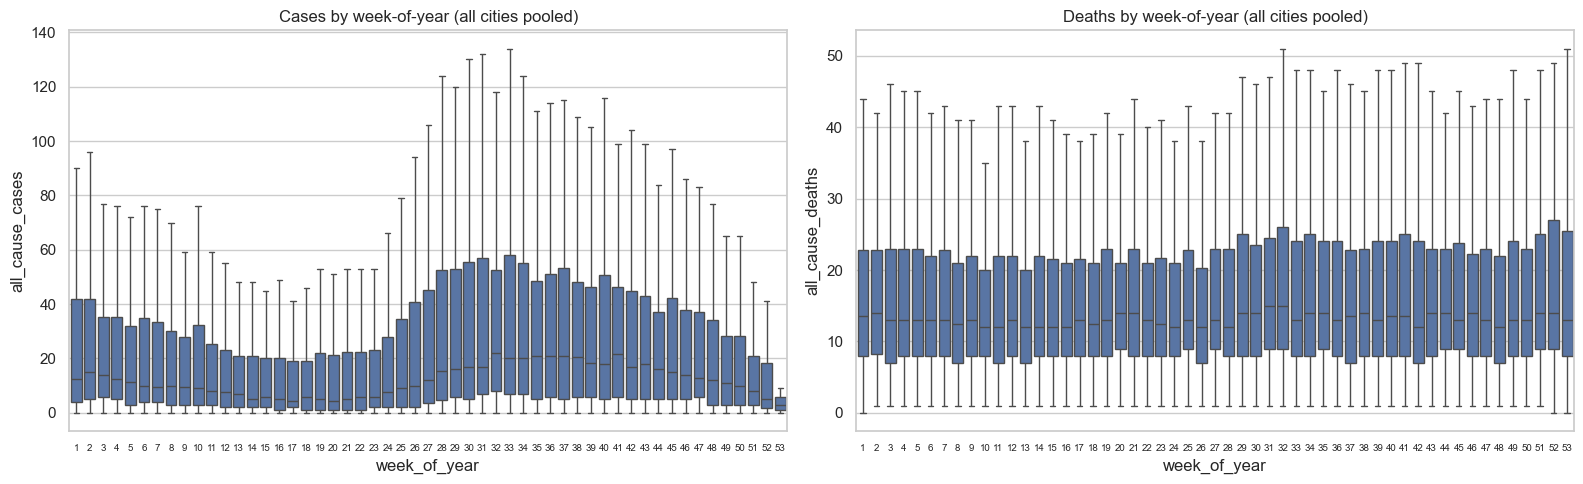

In [25]:
# Week-of-year seasonality
target_w["week_of_year"] = target_w["date"].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=target_w, x="week_of_year", y="all_cause_cases", ax=axes[0], showfliers=False)
axes[0].set_title("Cases by week-of-year (all cities pooled)")
sns.boxplot(data=target_w, x="week_of_year", y="all_cause_deaths", ax=axes[1], showfliers=False)
axes[1].set_title("Deaths by week-of-year (all cities pooled)")
for ax in axes:
    ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
plt.show()

## 5. Climate-table column inventory

In [26]:
CLIMATE_FILES = [
    "climate_air_quality.csv",
    "climate_atmosphere.csv",
    "climate_atmosphere_downscaled.csv",
    "climate_indices.csv",
    "climate_land.csv",
]

climate_presence = {}
for name in CLIMATE_FILES:
    cols = schemas[name]["columns"]
    climate_presence[name] = {
        "columns": cols,
    }

for name, info in climate_presence.items():
    print(f"--- {name} ---")
    print("  cols  :", info["columns"])
    print()

--- climate_air_quality.csv ---
  cols  : ['uuid', 'adm4_pcode', 'date', 'freq', 'no2', 'co', 'so2', 'o3', 'pm10', 'pm25']

--- climate_atmosphere.csv ---
  cols  : ['uuid', 'adm4_pcode', 'date', 'freq', 'tave', 'tmin', 'tmax', 'heat_index', 'pr', 'wind_speed', 'rh', 'solar_rad', 'uv_rad']

--- climate_atmosphere_downscaled.csv ---
  cols  : ['uuid', 'adm4_pcode', 'date', 'freq', 'tmin_downscaled', 'tmax_downscaled', 'tave_downscaled', 'pr_downscaled']

--- climate_indices.csv ---
  cols  : ['uuid', 'adm4_pcode', 'date', 'freq', 'pr_norm', 'spi3', 'spi6', 'pnp']

--- climate_land.csv ---
  cols  : ['uuid', 'adm4_pcode', 'date', 'freq', 'ndvi']



## 6. Joinability checks

Confirm the 12 target cities are present in `location.csv` and that every adm3_pcode used by PIDSR / PSA exists in `location.csv`.

In [27]:
loc = pd.read_csv(DATA_DIR / "location.csv")
print("location.csv adm3 unique:", loc["adm3_pcode"].nunique())
print("location.csv adm4 unique:", loc["adm4_pcode"].nunique())

cities_pidsr = set(pidsr["adm3_pcode"].unique())
cities_psa = set(psa["adm3_pcode"].unique())
cities_loc = set(loc["adm3_pcode"].unique())

print("\nPIDSR ADM3 in PIDSR but not in location.csv:", cities_pidsr - cities_loc)
print("PSA   ADM3 in PSA   but not in location.csv:", cities_psa - cities_loc)
print("\nCity overlap PIDSR ∩ PSA:", len(cities_pidsr & cities_psa))
print("City overlap PIDSR ∩ PSA ∩ location.csv:", len(cities_pidsr & cities_psa & cities_loc))

target_cities = sorted(cities_pidsr & cities_psa & cities_loc)
print("\nTarget cities (intersection of all three):")
city_dim = loc.drop_duplicates("adm3_pcode")[["adm3_pcode", "adm3_en"]]
display(city_dim[city_dim["adm3_pcode"].isin(target_cities)])

location.csv adm3 unique: 12
location.csv adm4 unique: 879

PIDSR ADM3 in PIDSR but not in location.csv: set()
PSA   ADM3 in PSA   but not in location.csv: set()

City overlap PIDSR ∩ PSA: 12
City overlap PIDSR ∩ PSA ∩ location.csv: 12

Target cities (intersection of all three):


,adm3_pcode,adm3_en
0,PH015518000,Dagupan City
4,PH034919000,Palayan City
6,PH050506000,Legazpi City
18,PH063022000,Iloilo City
44,PH072230000,Mandaue City
50,PH083747000,Tacloban City
72,PH097332000,Zamboanga City
84,PH104305000,Cagayan de Oro City
95,PH112402000,Davao City
127,PH137401000,City of Mandaluyong


## 7. Coverage matrix

For each target table, build a (city × year) row-count matrix. Empty cells become NaNs downstream so we want to know where they are *before* training.

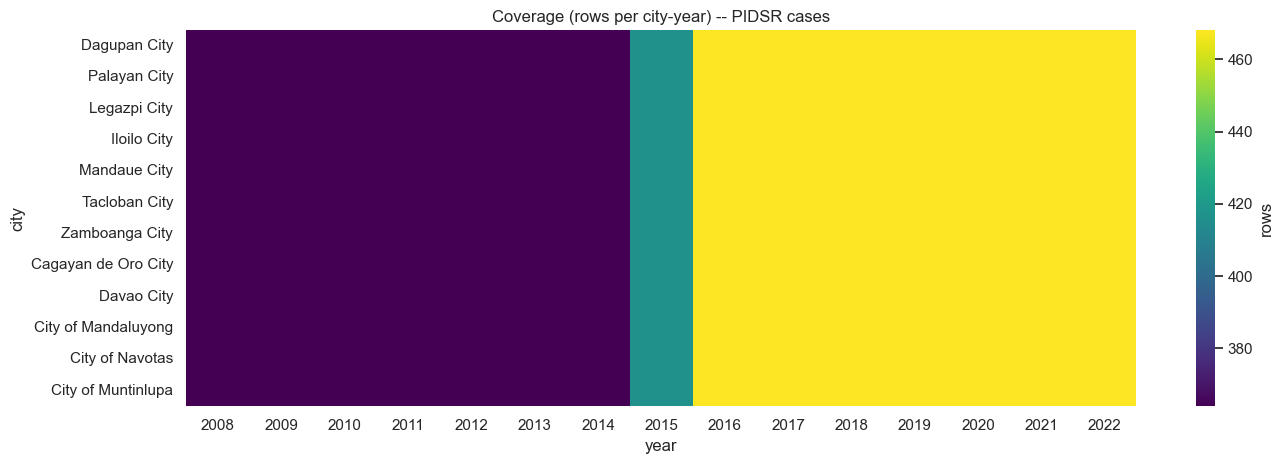

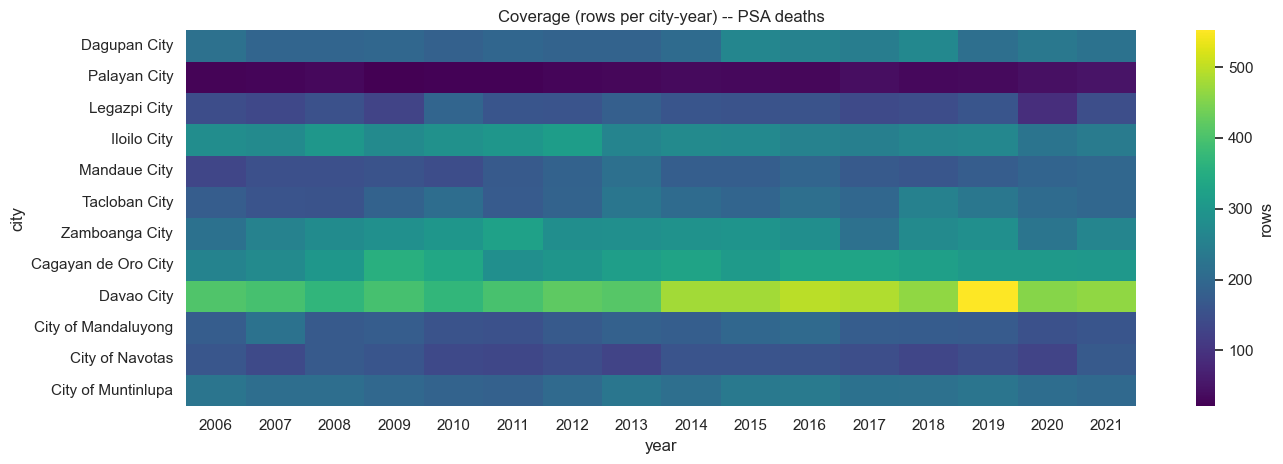

In [28]:
def coverage_matrix(df, label):
    df = df.copy()
    df["year"] = df["date"].dt.year
    mat = df.groupby(["adm3_pcode", "year"]).size().unstack("year").fillna(0).astype(int)
    # restrict to target cities for legibility
    mat = mat.loc[mat.index.isin(target_cities)]
    # map ADM3 pcode index to readable city names (fall back to pcode if missing)
    mat.index = [pcode_to_name.get(pc, pc) for pc in mat.index]
    fig, ax = plt.subplots(figsize=(14, max(3, 0.4 * len(mat))))
    sns.heatmap(mat, cmap="viridis", cbar_kws={"label": "rows"}, ax=ax)
    ax.set_title(f"Coverage (rows per city-year) -- {label}")
    ax.set_ylabel("city")
    plt.tight_layout()
    plt.show()
    return mat

_ = coverage_matrix(pidsr, "PIDSR cases")
_ = coverage_matrix(psa, "PSA deaths")

## 8. Feature group inventories

For each non-climate feature table, capture: date range (if time-varying), distinct ADM3/ADM4 counts, and missingness on numeric columns.

In [29]:
FEATURE_FILES = [
    "worldpop_population.csv",
    "nighttime_lights.csv",
    "ookla_internet_speed.csv",
    "tm_relative_wealth_index.csv",
    "osm_poi_amenity.csv",
    "osm_poi_health.csv",
    "osm_poi_sanitation.csv",
    "osm_poi_total.csv",
    "osm_poi_water_body.csv",
    "tm_open_buildings.csv",
    "google_open_buildings.csv",
    "esa_worldcover.csv",
    "project_noah_hazards.csv",
    "brgy_geography.csv",
    "mapbox_health_facility_city_isochrones.csv",
    "mapbox_health_facility_brgy_isochrones.csv",
    "geoportal_doh_poi_health.csv",
]

feature_summaries = []
for name in FEATURE_FILES:
    path = DATA_DIR / name
    df = pd.read_csv(path)
    rec = {"file": name, "rows": len(df), "n_cols": df.shape[1]}
    for k in ("adm3_pcode", "adm4_pcode"):
        rec[f"n_{k}"] = df[k].nunique() if k in df.columns else None
    if "date" in df.columns:
        d = pd.to_datetime(df["date"], errors="coerce")
        rec["date_min"] = d.min()
        rec["date_max"] = d.max()
    numerics = df.select_dtypes(include=[np.number]).columns.tolist()
    rec["n_numeric_cols"] = len(numerics)
    rec["max_null_pct"] = float(df[numerics].isna().mean().max()) * 100 if numerics else None
    rec["mean_null_pct"] = float(df[numerics].isna().mean().mean()) * 100 if numerics else None
    feature_summaries.append(rec)

feat_summary_df = pd.DataFrame(feature_summaries)
feat_summary_df

,file,rows,n_cols,n_adm3_pcode,n_adm4_pcode,date_min,date_max,n_numeric_cols,max_null_pct,mean_null_pct
0,worldpop_population.csv,18459,15,NaN,879.0,2000-01-01,2020-01-01,11,42.207053,19.247078
1,nighttime_lights.csv,9669,9,NaN,879.0,2012-01-01,2022-01-01,5,23.777019,23.777019
2,ookla_internet_speed.csv,3516,14,NaN,879.0,2019-01-01,2022-01-01,10,3.071672,2.218430
3,tm_relative_wealth_index.csv,6153,9,NaN,879.0,2016-01-01,2022-01-01,5,7.508532,1.501706
4,osm_poi_amenity.csv,7911,38,NaN,879.0,2014-01-01,2022-01-01,34,0.000000,0.000000
5,osm_poi_health.csv,7911,16,NaN,879.0,2014-01-01,2022-01-01,12,0.000000,0.000000
6,osm_poi_sanitation.csv,7911,25,NaN,879.0,2014-01-01,2022-01-01,21,0.000000,0.000000
7,osm_poi_total.csv,7911,5,NaN,879.0,2014-01-01,2022-01-01,1,0.000000,0.000000
8,osm_poi_water_body.csv,7911,13,NaN,879.0,2014-01-01,2022-01-01,9,0.000000,0.000000
9,tm_open_buildings.csv,12369,12,12.0,87.0,NaT,NaT,2,0.606355,0.303177


## 9. Per-feature missingness + variance (drives keep/drop)

For every numeric column in every feature table, compute % missing and standard deviation across the 12 target cities. The decision rule for the inventory:

* **drop** if missing % > 50 or std == 0 (constant)
* **keep** otherwise

In [30]:
ID_LIKE = {
    "adm1_pcode", "adm2_pcode", "adm3_pcode", "adm4_pcode", "adm1_en", "adm2_en", "adm3_en", "adm4_en",
    "uuid", "date", "freq", "source_name", "source_filename", "disease_icd10_code", "disease_common_name",
    "geometry", "year", "month", "week",
}

feature_rows = []
for name in FEATURE_FILES:
    df = pd.read_csv(DATA_DIR / name)
    if "adm3_pcode" in df.columns:
        df = df[df["adm3_pcode"].isin(target_cities)]
    elif "adm4_pcode" in df.columns:
        # restrict to ADM4s that fall within the target cities via location.csv
        keep_adm4 = loc[loc["adm3_pcode"].isin(target_cities)]["adm4_pcode"].unique()
        df = df[df["adm4_pcode"].isin(keep_adm4)]
    for col in df.columns:
        if col in ID_LIKE:
            continue
        s = df[col]
        if not pd.api.types.is_numeric_dtype(s):
            continue
        miss = float(s.isna().mean()) * 100
        std = float(s.std(skipna=True)) if s.notna().any() else 0.0
        decision = "drop" if (miss > 50 or std == 0 or np.isnan(std)) else "keep"
        reason = []
        if miss > 50:
            reason.append(f">50% missing ({miss:.1f}%)")
        if std == 0 or np.isnan(std):
            reason.append("zero variance")
        feature_rows.append({
            "source_file": name,
            "column": col,
            "granularity": TABLE_TAGS.get(name, {}).get("gran"),
            "key": TABLE_TAGS.get(name, {}).get("key"),
            "missing_pct": round(miss, 2),
            "std": std,
            "decision": decision,
            "notes": "; ".join(reason),
        })

feature_inventory = pd.DataFrame(feature_rows).sort_values(["source_file", "column"])
print("Total candidate feature columns:", len(feature_inventory))
print("Decisions:")
print(feature_inventory["decision"].value_counts())
feature_inventory

Total candidate feature columns: 196
Decisions:
decision
keep    192
drop      4
Name: count, dtype: int64


,source_file,column,granularity,key,missing_pct,std,decision,notes
141,brgy_geography.csv,brgy_distance_to_coast,static,adm4,0.00,3159.514108,keep,
142,brgy_geography.csv,brgy_is_coastal,static,adm4,0.00,0.428731,keep,
140,brgy_geography.csv,brgy_total_area,static,adm4,0.00,15.870369,keep,
119,esa_worldcover.csv,pct_area_bare_sparse_vegetation,static,adm4,0.00,1.305283,keep,
120,esa_worldcover.csv,pct_area_builtup,static,adm4,0.00,41.938993,keep,
...,...,...,...,...,...,...,...,...
10,worldpop_population.csv,pop_density_max,annual,adm4,42.21,9357.953416,keep,
6,worldpop_population.csv,pop_density_mean,annual,adm4,42.21,8662.470218,keep,
7,worldpop_population.csv,pop_density_median,annual,adm4,42.21,8653.556792,keep,
9,worldpop_population.csv,pop_density_min,annual,adm4,42.21,8511.431182,keep,


In [31]:
# Per-source rollup of how many features survive
feature_inventory.groupby(["source_file", "decision"]).size().unstack("decision").fillna(0).astype(int)

decision,drop,keep
source_file,,
brgy_geography.csv,0,3
esa_worldcover.csv,0,9
geoportal_doh_poi_health.csv,0,17
google_open_buildings.csv,0,8
mapbox_health_facility_brgy_isochrones.csv,0,18
mapbox_health_facility_city_isochrones.csv,0,18
nighttime_lights.csv,0,5
ookla_internet_speed.csv,0,10
osm_poi_amenity.csv,0,34


## 10. Climate-feature inventory (handled separately because of size)

For each climate CSV, sample the file and add per-variable rows to the inventory.

In [32]:
climate_rows = []
SAMPLE_ROWS = 200_000

for name in CLIMATE_FILES:
    info = climate_presence[name]
    path = DATA_DIR / name

    df = pd.read_csv(path, nrows=SAMPLE_ROWS)
    for col in df.columns:
        if col in ID_LIKE or not pd.api.types.is_numeric_dtype(df[col]):
            continue
        miss = float(df[col].isna().mean()) * 100
        std = float(df[col].std(skipna=True)) if df[col].notna().any() else 0.0
        decision = "drop" if (miss > 50 or std == 0 or np.isnan(std)) else "keep"
        climate_rows.append({
            "source_file": name,
            "column": col,
            "granularity": TABLE_TAGS[name]["gran"],
            "key": TABLE_TAGS[name]["key"],
            "missing_pct": round(miss, 2),
            "std": std,
            "decision": decision,
        })

climate_inventory = pd.DataFrame(climate_rows)
print("Climate candidate features:", len(climate_inventory))
print(climate_inventory["decision"].value_counts())
climate_inventory

Climate candidate features: 24
decision
keep    23
drop     1
Name: count, dtype: int64


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,source_file,column,granularity,key,missing_pct,std,decision
0,climate_air_quality.csv,no2,daily_or_weekly,adm4,0.00,1.220242,keep
1,climate_air_quality.csv,co,daily_or_weekly,adm4,0.00,0.017198,keep
2,climate_air_quality.csv,so2,daily_or_weekly,adm4,0.00,0.743840,keep
3,climate_air_quality.csv,o3,daily_or_weekly,adm4,0.00,5.652527,keep
4,climate_air_quality.csv,pm10,daily_or_weekly,adm4,0.00,9.070332,keep
5,climate_air_quality.csv,pm25,daily_or_weekly,adm4,0.00,6.457892,keep
6,climate_atmosphere.csv,tave,daily_or_weekly,adm4,0.00,1.255934,keep
7,climate_atmosphere.csv,tmin,daily_or_weekly,adm4,0.00,1.234802,keep
8,climate_atmosphere.csv,tmax,daily_or_weekly,adm4,0.00,1.788718,keep
9,climate_atmosphere.csv,heat_index,daily_or_weekly,adm4,0.00,2.469298,keep


## 11. Write the feature inventory

Concatenate the non-climate and climate inventories and write to `feature_inventory.csv`.

In [36]:
full_inventory = pd.concat([feature_inventory, climate_inventory], ignore_index=True)
out_path = EDA_OUT / "feature_inventory.csv"
full_inventory.to_csv(out_path, index=False)
print("Wrote:", out_path)
print("Total rows:", len(full_inventory))
print(full_inventory["decision"].value_counts())

# Also persist the target-city list
(EDA_OUT / "target_adm3_pcodes.json").write_text(json.dumps(sorted(target_cities), indent=2))
print("\nTarget ADM3 city list written to:", EDA_OUT / "target_adm3_pcodes.json")

Wrote: /Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/data/processed/eda/feature_inventory.csv
Total rows: 220
decision
keep    215
drop      5
Name: count, dtype: int64

Target ADM3 city list written to: /Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/data/processed/eda/target_adm3_pcodes.json


## 12. Summary -- features available for modelling

The next steps in the pipeline consume `feature_inventory.csv` and `target_adm3_pcodes.json`. Read the `decision` column to filter to the surviving feature set.

Quick reference for what is modelable:

* **Target candidates** -- `all_cause_cases` (PIDSR weekly), `all_cause_deaths` (PSA weekly) at ADM3.
* **Time-varying features** -- 19 climate variables (5 climate CSVs), nighttime lights (annual), ookla speeds (annual), RWI (annual), OSM POI counts (annual or static), worldpop (annual), buildings (mostly static).
* **Static features** -- ESA worldcover %, NOAH hazard %, brgy_geography (area, distance-to-coast), Mapbox isochrone access metrics, DOH facility counts.
* **Dropped (auto-rejected)** -- any column with >50% missing or zero variance among the 12 target cities. See `feature_inventory.csv` for the per-column verdict.